# Analysis of Regional and Varietal Signatures in Wine

As a wine enthusiast (and certified sommelier) I'm interested in how flavor, geography, and craftsmanship combine to create a great bottle of wine. For my extra credit project, I wanted to use this interest to explore the patterns hidden within expert reviews by examining the language, pricing, and evaluation of wines across the globe.

This analysis looks at a dataset of Wine Enthusiast Magazine reviews to uncover relationships between a wine's origin, variety, description, and perceived quality. My analysis focuses on several questions:

- Do regional signatures exist in wine descriptions? Can we identify distinct vocabulary patterns that differentiate wines from various regions?
- Do variety-based signatures exist in wine descriptions? Can we identify distinct vocabulary patterns that differentiate various varietals of wine?
- Where is the optimal value threshold? As a wine consumer, I'm particularly interested in identifying the "sweet spot" where quality and affordability intersect in order to find exceptional wines that don't demand premium prices.

The dataset comprises 49,999 randomly sampled reviews from Wine Enthusiast magazine, collected on November 22nd, 2017. Each entry contains detailed information including the wine's country of origin, region, variety, winery, price, rating points, and a descriptive review from a named critic. The complete dataset is available on [Kaggle](https://www.kaggle.com/datasets/zynicide/wine-reviews/data).

<h4>Part 1: Exploratory Data Analysis</h4>

Before modifying the dataset and conducting any specific analyses, I wanted to examine the original dataset's structure and content to decide the best approach to take to answer my project's questions. I looked at the first five rows of data to understand what information is captured in the dataset, as well as the size, object types, and any null vs. unique values to help me understand if there are any gaps in the data and how best to manipulate the data. 

In [1]:
#Import libraries for future use
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

#Read in CSV
wine = pd.read_csv("winemag-data-random-sample.csv")
wine = wine.drop('Unnamed: 0', axis=1)

#Print first 5 rows
display(wine.head())

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Argentina,Aromas of sweet melon and honey suggest an inn...,Coleccion,83,12.0,Other,Calchaquí Valley,NaN,Michael Schachner,@wineschach,Michel Torino 2006 Coleccion Chardonnay (Calch...,Chardonnay,Michel Torino
1,France,"This is fruity, fragrant and fresh. It has cre...",The Furst,85,NaN,Alsace,Alsace,NaN,Roger Voss,@vossroger,Cave de Kientzheim-Kaysersberg 2010 The Furst ...,Pinot Blanc,Cave de Kientzheim-Kaysersberg
2,France,"Full of very ripe fruit, this is soft and smoo...",La Rue de Vergy,89,NaN,Burgundy,Morey-Saint-Denis,NaN,Roger Voss,@vossroger,Domaine Perrot-Minot 2010 La Rue de Vergy (Mo...,Pinot Noir,Domaine Perrot-Minot
3,Italy,"Blue flower, woodland berry, cake spice, menth...",Narin,92,NaN,Piedmont,Barbaresco,NaN,Kerin O’Keefe,@kerinokeefe,Carlo Giacosa 2013 Narin (Barbaresco),Nebbiolo,Carlo Giacosa
4,US,This is a wine for those who crave density and...,NaN,93,30.0,California,Paso Robles,Central Coast,Matt Kettmann,@mattkettmann,San Simeon 2013 Petite Sirah (Paso Robles),Petite Sirah,San Simeon


In [2]:
#Show size, data types, column names, and null vs. unique values
print("Dimensions:\n", wine.shape, "\n")
print("Description:\n", wine.describe(), "\n")
print("Column names:\n", wine.columns.tolist(), "\n")
print("Data types:\n", wine.dtypes, "\n")
print("Null values:\n", wine.isnull().sum(), "\n")
print("Unique values:\n", wine.nunique(), "\n")

Dimensions:
 (49999, 13) 

Description:
              points         price
count  49999.000000  46527.000000
mean      88.442429     35.202785
std        3.034022     41.011626
min       80.000000      4.000000
25%       86.000000     17.000000
50%       88.000000     25.000000
75%       91.000000     42.000000
max      100.000000   3300.000000 

Column names:
 ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'variety', 'winery'] 

Data types:
 country                   object
description               object
designation               object
points                     int64
price                    float64
province                  object
region_1                  object
region_2                  object
taster_name               object
taster_twitter_handle     object
title                     object
variety                   object
winery                    object
dtype: object 

Null valu

This data set includes a lot of information about each wine review:  the wines country of origin, review description, designation (the vineyard where the wine is from), points (how Wine Enthusiast rates wine, out of 100 points), price per bottle, province, region (and potentially subregion), taster name, taster Twitter handle, name of the wine, variety of grapes, and the winery. While I'm not going to use all columns for analysis, the detail provided offers some interesting future areas of exploration. 

In exploring the data I noticed a large value of null values. For some reviews this is due to lack of information for specific reviews, while for others it is because the value is irrelevant (for instance, some countries to not specify the subregion of wines). I'll need to take this into account when cleaning up and analyzing the data.

<h4>Part 2: Data Cleanup</h4>

Now that I have a better understanding of the dataset contents and structure, I modified the data set to improve the usability of the data and make it easier to analyze. This included renaming some of the column names, filling in blank values as "Unknown," and changing the object type of price to make it easier to perform operations. 

In [3]:
#Rename select columns
wine = wine.rename(columns={
    'region_1':'region', 'region_2': 'subregion', 'taster_name': 'taster name', 'taster_twitter_handle': 'taster twitter'})

#Fill in null values
wine = wine.fillna("Unknown")

#Change price values to numeric for future analysis
wine['price'] = pd.to_numeric(wine['price'], errors='coerce')

In my exploratory data analysis, I noticed that there were a number of wines that only had one review associated with the varietal or country. In order to better represent the data and identify patterns in country and varietal, I decided to only run analyses on varietals and countries with over 100 reviews. I also removed any reviews with country or varietal as "Unknown" as they won't be relevant in my analysis. That brought the number of rows down from 49,999 to 44,149.

In [4]:
#Remove unknown values for country and variety
wine2 = wine[wine['country'] != 'Unknown']
wine2 = wine2[wine2['variety'] != 'Unknown']

#Remove varieties with fewer than 100 reviews
variety_counts = wine2['variety'].value_counts()
v_bool = wine2['variety'].map(lambda x: variety_counts[x] >= 100)
wine2 = wine2[v_bool]

#Remove countries with fewer than 100 reviews
country_counts = wine2['country'].value_counts()
c_bool = wine2['country'].map(lambda x: country_counts[x] >= 100)
wine2 = wine2[c_bool]

print(wine2.shape)

(44149, 13)


Given I am especially interested in patterns of the wine descriptions, I wanted to create a new column for tasting notes that highlights common wine descriptors that appear in the reviews. To do this, I took the "description" column, removed the stopwords, and took a look at the most common descriptor words to check my work. I then pulled a list of approximately 100 common wine tasting notes (some without ending to account for different versions of the same word, like tannic and tannins), and if the description mentioned one of those words it was added to the new "tasting_notes" column.

In [5]:
stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours','ourselves', 'you', "you're", "you've", "you'll", 
             "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 
             'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
             'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are',
             'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing',
             'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 
             'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 
             'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 
             'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 
             'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 
             's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 
             're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 
             'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn',
             "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 
             'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

#Function to remove stopwords and punctuation from descriptions
def descriptor_words(text):
    text_lower = text.lower()
    text_cleaned = re.sub(r'[^\w\s]', '', text_lower)
    words = text_cleaned.split()
    found_words = []
    
    for word in words:
        if word not in stopwords:
            found_words.append(word)
    
    return found_words

#Create and display new column of descriptions without the descriptor words
wine2['descriptor_words'] = wine2['description'].apply(descriptor_words)
display(wine2[['description', 'descriptor_words']].head())

#Count and show most common words in description
all_descriptors = [desc for sublist in wine2['descriptor_words'].tolist() for desc in sublist]
print('\nMost common words:\n', Counter(all_descriptors).most_common(25))

,description,descriptor_words
0,Aromas of sweet melon and honey suggest an inn...,"[aromas, sweet, melon, honey, suggest, innocuo..."
1,"This is fruity, fragrant and fresh. It has cre...","[fruity, fragrant, fresh, creamed, pear, tangy..."
2,"Full of very ripe fruit, this is soft and smoo...","[full, ripe, fruit, soft, smooth, beginning, s..."
3,"Blue flower, woodland berry, cake spice, menth...","[blue, flower, woodland, berry, cake, spice, m..."
4,This is a wine for those who crave density and...,"[wine, crave, density, ripeness, black, curran..."



Most common words:
 [('wine', 26866), ('flavors', 21342), ('fruit', 15166), ('aromas', 12629), ('palate', 12293), ('acidity', 11548), ('finish', 11485), ('tannins', 10680), ('drink', 10438), ('cherry', 9454), ('ripe', 9334), ('black', 8728), ('red', 6370), ('notes', 6355), ('spice', 6264), ('rich', 5936), ('oak', 5744), ('nose', 5596), ('fresh', 5533), ('dry', 5469), ('berry', 5228), ('fruits', 4703), ('plum', 4679), ('soft', 4590), ('texture', 4372)]


In [6]:
#Pull in common wine descriptors
wine_descriptors = ["oak", "tann", "complex", "earth", "flo", "jam", "spic", "butter", "herb", "smok", 
                    "vanilla", "chocolate", "mineral", "leather", "tobacco", "pepper", "citrus", "berr", "plum", "strawberr", 
                    "peach", "cherr", "caramel", "nut", "grass", "veget", "honey", "tropical", "stone", "peat", "barn", 
                    "blackcurrant", "toast", "cedar", "blackberr", "bread", "mushroom", "melon", "raspberr", "apple", "licorice", 
                    "astringent", "balance", "bold", "crisp", "delicate", "dry", "full", "light", "medium", "slate"
                    "acid", "soft", "structure", "round", "robust", "elegant", "supple", "lean", "rich", "viscous", "velvet", 
                    "mature", "youth", "age", "approachable", "austere", "backward", "close", "develope", "evolve", "fad", 
                    "layer", "nuance", "opulent", "refine", "rustic", "texture", "vibrant", "concentrate", "fresh", "harmon", 
                    "long", "short", "linger", "clean", "bright", "live", "silk", "smooth", "power", "integrate", "green",
                    "expressive", "intense", "mellow", "firm", "juic", "tight", "vigor", "warm", "zip", "brac", "savor", "lemon",
                    "cream", "yeast", "salt", "menthol"]

#Create helper function for identifying descriptors in descriptions
def find_descriptors(text):
    text_lower = text.lower()
    found_descriptors = []
    
    for descriptor in wine_descriptors:
        pattern = r'\b' + re.escape(descriptor) + r'[a-z]*\b'
        if re.search(pattern, text_lower):
            found_descriptors.append(descriptor)
    
    return found_descriptors

#Create and display new column "tasting_notes"
wine2['tasting_notes'] = wine2['description'].apply(find_descriptors)
display(wine2[['description', 'tasting_notes']].head())

#Count and show most common tasting notes across reviews
all_notes = [desc for sublist in wine2['tasting_notes'].tolist() for desc in sublist]
print('\nMost common tasting notes:\n', Counter(all_notes).most_common(25))

,description,tasting_notes
0,Aromas of sweet melon and honey suggest an inn...,"[honey, melon, apple]"
1,"This is fruity, fragrant and fresh. It has cre...","[crisp, fresh, bright, cream]"
2,"Full of very ripe fruit, this is soft and smoo...","[plum, full, soft, structure, round, smooth, f..."
3,"Blue flower, woodland berry, cake spice, menth...","[tann, flo, spic, berr, strawberr, cherr, stru..."
4,This is a wine for those who crave density and...,"[tann, butter, chocolate, cherr, caramel, long..."



Most common tasting notes:
 [('tann', 13107), ('cherr', 10984), ('spic', 9758), ('rich', 7761), ('fresh', 6961), ('oak', 6591), ('dry', 6501), ('berr', 6033), ('full', 5757), ('light', 5747), ('plum', 5664), ('herb', 5663), ('soft', 5616), ('texture', 5361), ('blackberr', 4951), ('balance', 4917), ('crisp', 4608), ('apple', 4519), ('pepper', 4436), ('structure', 4388), ('toast', 3945), ('bright', 3923), ('juic', 3852), ('citrus', 3814), ('raspberr', 3785)]


<h4>Part 3: Summary Statistics</h4>

Before diving into some of my project questions, I wanted to gather some summary statistics to better understand what country and varietals were most and least favorably reviewed. I looked at common statistics including mean, minimum, maximum, and count (or number of reviews) for both points and price of the bottle. 

In [7]:
#Aggregate price and points summary statistics based on country
country_stats = wine2.groupby('country').agg({
    'points': ['mean', 'min', 'max', 'count'],
    'price': ['mean', 'min', 'max']})

country_stats = country_stats.sort_values(('points', 'mean'), ascending=False)

print('Highest rated countries on average:')
display(country_stats.head())
print('\nLowest rated countries on average:')
display(country_stats.tail().iloc[::-1])

Highest rated countries on average:


points                      price              
              mean min  max  count       mean   min     max
country                                                    
Austria  90.220547  82   97   1061  30.082867  10.0   134.0
Germany  89.894320  84   97    757  39.753053   8.0   445.0
France   88.870868  80  100   8077  42.452763   5.0  3300.0
Italy    88.831743  81  100   5765  44.211878   5.0   550.0
US       88.565233  80   99  20013  36.581058   4.0   750.0


Lowest rated countries on average:


points                     price            
                   mean min  max count       mean  min    max
country                                                      
Chile         86.471257  80   94  1583  20.378672  5.0  400.0
Argentina     86.717600  80   95  1250  24.450933  6.0  225.0
Spain         87.244770  80   97  1912  26.949762  5.0  325.0
South Africa  88.104121  82   95   461  24.439716  6.0  130.0
Portugal      88.273950  80  100  1785  26.240104  5.0  980.0

In [8]:
#Aggregate price and points summary statistics based on varietal
variety_stats = wine2.groupby('variety').agg({
    'points': ['mean', 'min', 'max', 'count'],
    'price': ['mean', 'min', 'max']})

variety_stats = variety_stats.sort_values(by=('points', 'mean'), ascending=False)

print('Highest rated varieties on average:')
display(variety_stats.head())
print('\nLowest rated varieties on average:')
display(variety_stats.tail().iloc[::-1])

Highest rated varieties on average:


points                     price             
                        mean min  max count       mean   min    max
variety                                                            
Sangiovese Grosso  90.508091  83  100   309  63.316456  15.0  270.0
Nebbiolo           90.203297  80   99  1092  64.592432  14.0  450.0
Grüner Veltliner   89.976654  82   96   514  26.198614  10.0  134.0
Blaufränkisch      89.841584  82   94   101  29.619048  12.0  100.0
Champagne Blend    89.746717  80   96   533  72.049251   8.0  469.0


Lowest rated varieties on average:


points                    price            
                   mean min max count       mean  min    max
variety                                                     
Garnacha      86.106061  80  93   132  23.446970  6.0  255.0
Pinot Grigio  86.165000  81  92   400  16.820312  5.0   52.0
Verdejo       86.226087  80  91   115  16.628319  8.0   50.0
Moscato       86.275000  80  94   120  16.553398  7.0   50.0
Carmenère     86.736111  80  94   216  21.507042  7.0  235.0

<h4>Part 4: Descriptor Analysis</h4>

Now that I have an idea of the highest and lowest rated countries and varieties I want to dive into the core of my analysis, which is identifying if there are any common characteristics in how certain varieties and countries are described. To start, I only kept the reviews with tasting notes (i.e. those that had descriptors that matched the 100 common descriptors above). Then I wanted to count of how frequently each tasting note appears in each country relative to the total number of reviews to see what tasting notes are most common by country. Finally I wanted to calculate a "distinctiveness" score to understand if there are any words that are used more common in one country vs. others. 

In [9]:
#Keep only the rows that have tasting notes
wine_filtered = wine2[wine2['tasting_notes'].str.len() > 0]

#Give each tasting note its own line to make it easier to count
wine_exp = wine_filtered.explode('tasting_notes')

#Helper functions for future analysis

def analyze_notes(df, group_field, top_n=5):
    """Returns note counts, percentages, and distinctiveness for a group_field"""
    #Calculate the tasting notes by group_field
    counts = df.groupby([group_field, 'tasting_notes']).size().reset_index(name='count')
    
    #Calculate the frquency of tasting notes in a group_fields's reviews
    totals = df[group_field].value_counts()
    counts['total_reviews'] = counts[group_field].map(totals)
    counts['percentage'] = (counts['count'] / counts['total_reviews']) * 100
    
    #Calculate distinctiveness of group_fields's tasting notes relative to other group_fields
    overall_freq = df['tasting_notes'].value_counts(normalize=True) * 100
    counts['overall_percentage'] = counts['tasting_notes'].map(overall_freq.to_dict())
    counts['distinctiveness'] = counts['percentage'] - counts['overall_percentage']
    
    return counts

def get_top_notes(df, group_field, top_n=5):
    """Returns n top notes for a group_field"""
    top_notes = (df.sort_values([group_field, 'count'], ascending=[True,False])
    .groupby(group_field)
    .apply(lambda x: ", ".join(x.nlargest(top_n, 'count')['tasting_notes']))
    .reset_index()
    .rename(columns={0: 'top_notes'}))
    
    return top_notes

def plot_distinct(df, group_field, group_list, top_n=5):
    """Plot most distinctive notes for each group in group_list"""
    plt.figure(figsize=(12, 10))
    for i, group_value in enumerate(group_list):
        group_data = (df[df[group_field] == group_value]
                      .sort_values('distinctiveness', ascending=False)
                      .head(top_n))
        plt.subplot(len(group_list), 1, i+1)
        sns.barplot(data=group_data, x='distinctiveness', y='tasting_notes')
        plt.title(f'Most Distinctive Tasting Notes for {group_value}')
        plt.xlabel('Distinctiveness Score (%)')
        plt.tight_layout()
    
    plt.tight_layout(pad=3.0)
    plt.show()

Top tasting notes by country:


,country,top_notes
0,Argentina,"berr, plum, oak, herb, spic"
1,Australia,"full, texture, tann, medium, vanilla"
2,Austria,"fresh, light, lemon, spic, pepper"
3,Chile,"herb, berr, plum, oak, spic"
4,France,"tann, rich, fresh, texture, structure"
5,Germany,"dry, mineral, peach, lemon, honey"
6,Israel,"tann, cherr, soft, pepper, plum"
7,Italy,"cherr, tann, spic, berr, flo"
8,New Zealand,"medium, cherr, herb, long, citrus"
9,Portugal,"tann, rich, structure, texture, soft"


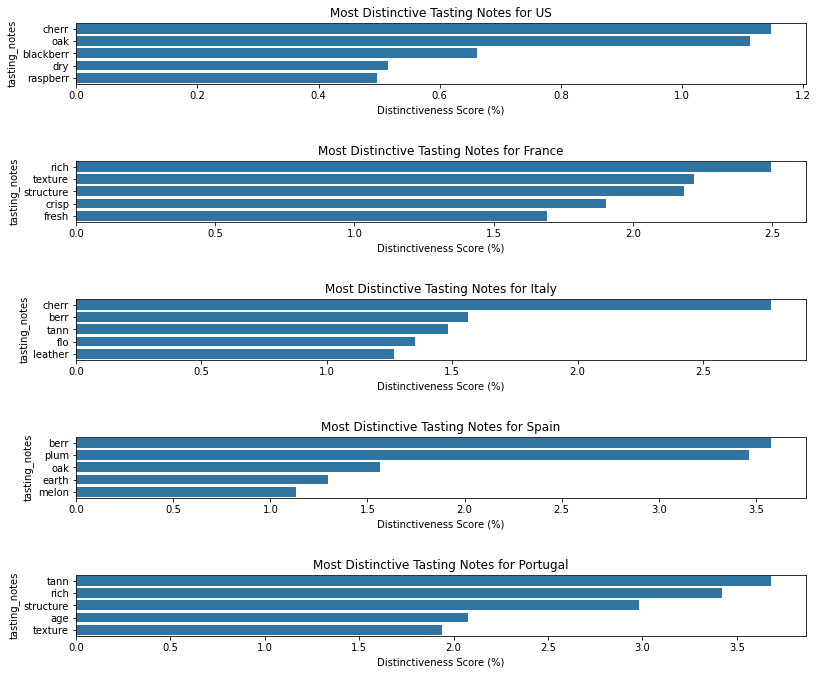

In [10]:
country_stats = analyze_notes(wine_exp, 'country')
top_notes_country = get_top_notes(country_stats, 'country')
country_list = wine_exp['country'].value_counts().head(5).index.tolist()
print('Top tasting notes by country:')
display(top_notes_country)
print('\n')
plot_distinct(country_stats, 'country', country_list, 5)

A couple of initial observation from running this code:
- There are clear differences in how wines from different countries are described. For instance, French wines emphasize "tannin," "rich," "fresh," and "texture" while Italian wines highlight "cherry," "berry," "spice," and "floral."
- Oak appears in wines from Argentina, Chile, Spain (one exception), and the United States, suggesting oak aging is a defining characteristic of New World (aka North and South American) wine. 
- Structural descriptors like "full," "medium," "crisp," and "texture" vary across regions, potentially reflecting stylistic differences in how the wine is made. 

Next, I wanted to run a similar analysis on the wine varieties to see if there are any commonalities amongst the same varieties. I wanted to count how frequently each tasting note appears in each variety to see what tasting notes are most common by variety. I also wanted to calculate a "distinctiveness" score to understand if there are any words that are used more common in one variety vs. others.

Top tasting notes by variety:


,variety,top_notes
0,Aglianico,"tann, spic, cherr, plum, firm"
1,Albariño,"apple, melon, citrus, peach, mineral"
2,Barbera,"cherr, spic, tann, berr, plum"
3,Blaufränkisch,"fresh, tann, cherr, spic, structure"
4,Bordeaux-style Red Blend,"tann, structure, rich, firm, spic"
5,Bordeaux-style White Blend,"rich, crisp, texture, spic, herb"
6,Cabernet Franc,"tann, cherr, herb, spic, rich"
7,Cabernet Sauvignon,"tann, cherr, blackberr, oak, herb"
8,Carmenère,"herb, berr, plum, spic, oak"
9,Champagne Blend,"crisp, texture, rich, soft, apple"


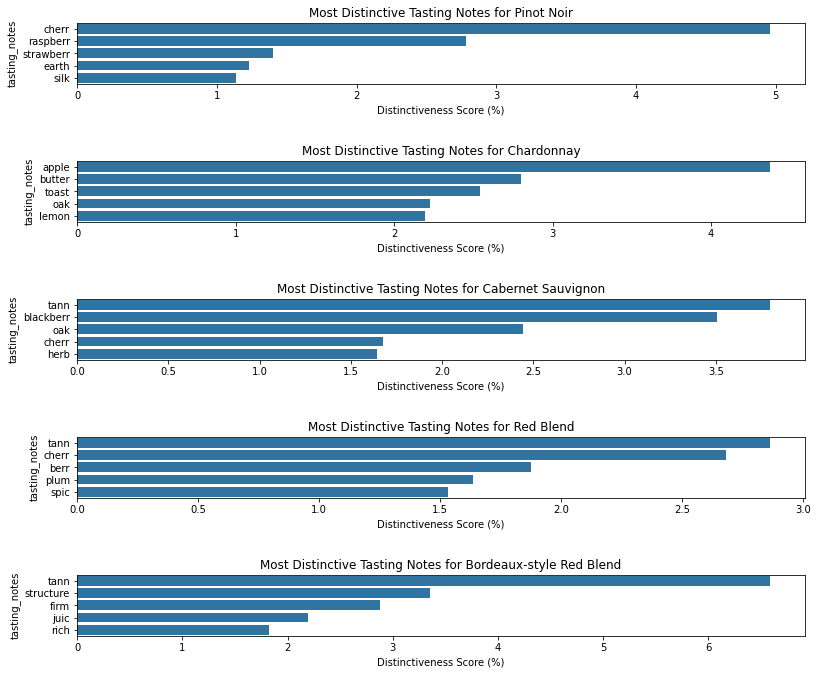

In [11]:
variety_stats = analyze_notes(wine_exp, 'variety')
top_notes_variety = get_top_notes(variety_stats, 'variety')
variety_list = wine_exp['variety'].value_counts().head(5).index.tolist()
print('Top tasting notes by variety:')
display(top_notes_variety)
print('\n')
plot_distinct(variety_stats, 'variety', variety_list, 5)

Some initial observations from this analysis:
- Red varieties and white varieties have a large difference in descriptors, with reds showing "tannins" and fruit notes like "cherry" and "berry," and whites with "apple," "crisp," and "fresh."
- While "spice" appears prominently across varieties, Gewurztraminer is the only white wine with spice as a leading descriptor.
- Viognier is notable as the only white grape with "tropical" in its top notes.

Now that I've looked at varietals and countries separately, I wanted to see  how flavor profiles for specific wine varietals differ across countries. I grouped the data by country and tasting note, then calculated the percentage of each note in the total reviews by country. Finally, I plotted a heatmap to visually compare the most common tasting notes across different countries in the three most popular varietals: Pinot Noir, Chardonnay, and Cabernet Sauvignon.

Most popular varietals:
 ['Pinot Noir', 'Chardonnay', 'Cabernet Sauvignon']


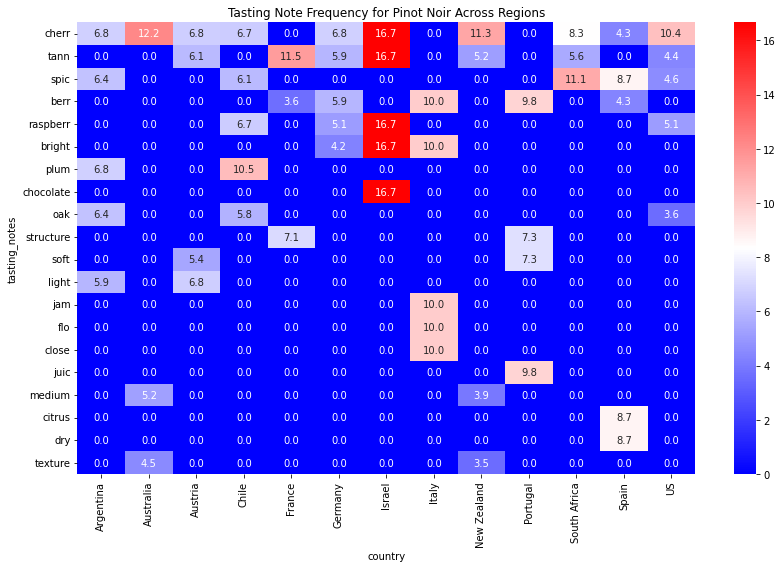

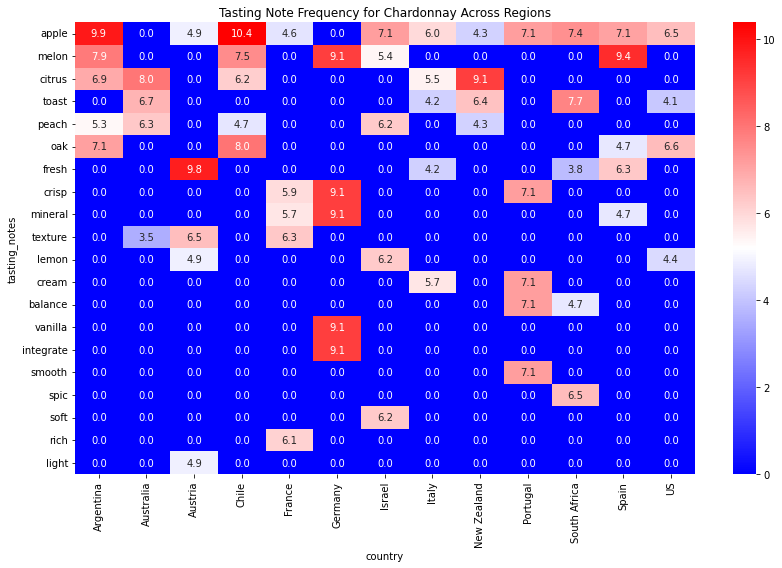

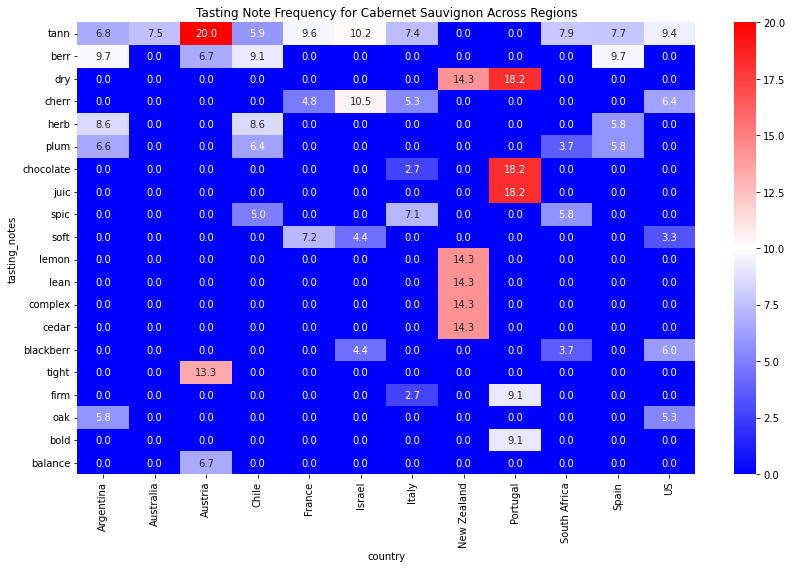

In [12]:
def compare_varietal_notes(varietal):
    """Plot heatmap of how tasting notes vary by country and variety"""
    #Filter for the specific varietal
    varietal_data = wine_filtered[wine_filtered['variety'] == varietal]
    
    #Explode tasting notes for this varietal
    varietal_exp = varietal_data.explode('tasting_notes')

    #Get note counts by country for this varietal
    varietal_notes = (varietal_exp.groupby(['country', 'tasting_notes'])
                      .size()
                      .reset_index(name='count'))

    #Calculate percentages
    country_totals = varietal_exp['country'].value_counts()
    varietal_notes['total_reviews'] = varietal_notes['country'].map(country_totals)
    varietal_notes['percentage'] = (varietal_notes['count'] / varietal_notes['total_reviews']) * 100

    #Get top notes for each country for this varietal
    top_varietal_notes = (varietal_notes.sort_values(['country', 'percentage'], ascending=[True, False])
            .groupby('country')
            .head(5))

    #Pivot for visualization, showing only notes that appear in more than one country
    pivot_data = top_varietal_notes.pivot_table(index='tasting_notes', columns='country', values='percentage', fill_value=0)
    pivot_data = pivot_data.loc[pivot_data.sum(axis=1).sort_values(ascending=False).head(20).index]

    #Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_data, cmap='bwr', annot=True, fmt='.1f')
    plt.title(f'Tasting Note Frequency for {varietal} Across Regions')
    plt.tight_layout()
    plt.show()

#Compare popular varietals
top_varietals = wine_filtered['variety'].value_counts().nlargest(3).index
print('Most popular varietals:\n', list(top_varietals))
for varietal in top_varietals:
    compare_varietal_notes(varietal)

Now that I've combined regional and varietal descriptors for Pinot Noir, Chardonnay, and Cabernet Sauvignon, I can see even more unique signatures based on the wine's classification. Some of these include:
- Regional signature styles: there are differences in how Old World and New World wine-producing countries are described and how they approach their winemaking. One good example of this is in the Chardonnay heatmap - US shows prominent "butter" and "oak" while France is characterized by "crisp" and "texture," highlighting the difference in the style of the same grape.
- Unique regional markers: There are unique characteristic of regions that appear consistently regardless of grape variety. Examples of this include Australia's high tannins, Israel's complexity and balance, and Portugal's acid-forward wines. 
- Climate influence: Temperature and growing conditions can drastically change the flavor profile of a wine. Warm climate regions like Australia and Argentina have tasting notes emphasizing ripe fruits, while cooler climate regions like New Zealand and Germany havve lighter fruit descriptors and heavily rely on acid. 

<h4>Part 5: Value Analysis</h4>

The last thing I wanted to explore (maybe a bit selfishly, to help me next time I'm buying wine) is the relationship between points and price. Are there wines that are highly rated but also still affordable? To find this, I started by standardizing the price and points values using z-score normalization. I then calculated a "value score" by subtracting the standardized price and the standardized points, showing how well each wine is rated relative to its price. Any wines with a value z-score above 0 are the ones that offer the most value. 

In [13]:
wine_val = wine2.copy()
#Drop any null values from analysis
wine_val = wine_val.dropna(subset=['price', 'points'])

#Compute mean and standard deviation for price and points
price_mean = wine_val['price'].mean()
price_sd = wine_val['price'].std()
points_mean = wine_val['points'].mean()
points_sd = wine_val['points'].std()

#Z-score normalization
wine_val['price_z'] = (wine_val['price'] - price_mean) / price_sd
wine_val['points_z'] = (wine_val['points'] - points_mean) / points_sd

#Create value score (how much better a wine scores than expected for its price)
wine_val['value_z_score'] = wine_val['points_z'] - wine_val['price_z']

#Find best and worst value wines 
best_value_wines = wine_val.sort_values('value_z_score', ascending=False).reset_index(drop=True)
worst_value_wines = wine_val.sort_values('value_z_score', ascending=True).reset_index(drop=True)

#Show the 10 best and worst value wines
print("Best value wines:") 
display(best_value_wines[['title', 'price', 'points', 'variety', 'winery', 'country', 'region', 'value_z_score']].head(10))
print("\nWorst value wines:")
display(worst_value_wines[['title', 'price', 'points', 'variety', 'winery', 'country', 'region', 'value_z_score']].head(10))

Best value wines:


,title,price,points,variety,winery,country,region,value_z_score
0,Rulo 2007 Syrah (Columbia Valley (WA)),20.0,96,Syrah,Rulo,US,Columbia Valley (WA),2.833445
1,Donkey & Goat 2010 Fenaughty Vineyard Syrah (E...,35.0,97,Syrah,Donkey & Goat,US,El Dorado,2.806624
2,Pirouette 2008 Red Wine Red (Columbia Valley (...,50.0,98,Bordeaux-style Red Blend,Pirouette,US,Columbia Valley (WA),2.779802
3,Isole e Olena 2010 Chianti Classico,27.0,96,Red Blend,Isole e Olena,Italy,Chianti Classico,2.668781
4,Gramercy 2010 Lagniappe Syrah (Columbia Valley...,55.0,98,Syrah,Gramercy,US,Columbia Valley (WA),2.662185
5,Eichinger 2014 Gaisberg Reserve Riesling (Kamp...,28.0,96,Riesling,Eichinger,Austria,Unknown,2.645257
6,Domaines Schlumberger 2014 Saering Grand Cru R...,29.0,96,Riesling,Domaines Schlumberger,France,Alsace,2.621734
7,Foxen 2010 Block UU Bien Nacido Vineyard Chard...,32.0,96,Chardonnay,Foxen,US,Santa Maria Valley,2.551164
8,Cayuse 2009 En Chamberlin Vineyard Syrah (Wall...,75.0,99,Syrah,Cayuse,US,Walla Walla Valley (OR),2.517747
9,Boekenoogen 2007 Chardonnay (Santa Lucia Highl...,34.0,96,Chardonnay,Boekenoogen,US,Santa Lucia Highlands,2.504117



Worst value wines:


,title,price,points,variety,winery,country,region,value_z_score
0,Château les Ormes Sorbet 2013 Médoc,3300.0,88,Bordeaux-style Red Blend,Château les Ormes Sorbet,France,Médoc,-76.931644
1,Château Pétrus 2014 Pomerol,2500.0,96,Bordeaux-style Red Blend,Château Pétrus,France,Pomerol,-55.504659
2,Château Margaux 2009 Margaux,1900.0,98,Bordeaux-style Red Blend,Château Margaux,France,Margaux,-40.738541
3,Château Cheval Blanc 2010 Saint-Émilion,1500.0,100,Bordeaux-style Red Blend,Château Cheval Blanc,France,Saint-Émilion,-30.677109
4,Kopke 1935 Colheita White (Port),980.0,94,Port,Kopke,Portugal,Unknown,-20.401107
5,Château Haut-Brion 2013 Pessac-Léognan,932.0,97,Bordeaux-style White Blend,Château Haut-Brion,France,Pessac-Léognan,-18.293892
6,Olivier Leflaive 2014 Montrachet,886.0,97,Chardonnay,Olivier Leflaive,France,Montrachet,-17.211814
7,Château Ausone 2007 Saint-Émilion,850.0,95,Bordeaux-style Red Blend,Château Ausone,France,Saint-Émilion,-17.017031
8,Henschke 2010 Hill of Grace Shiraz (Eden Valley),820.0,96,Shiraz,Henschke,Australia,Eden Valley,-15.985298
9,Kopke 1941 Colheita Tawny (Port),770.0,93,Port,Kopke,Portugal,Unknown,-15.787217


In [14]:
#Group by variety and calculate mean value score
variety_value = (wine_val.groupby('variety')['value_z_score']
                 .agg(['mean', 'count'])
                 .sort_values('mean', ascending=False))

#Show the 10 best and worst value wine varieties
print("Best value wines varieties:") 
display(variety_value.head(5))
print("Worst value wines varieties:")
display(variety_value.tail(5).iloc[::-1])

#Group by country and calculate mean value score
country_value = (wine_val.groupby('country')['value_z_score']
                 .agg(['mean', 'count'])
                 .sort_values('mean', ascending=False))

#Show the 10 best and worst value wine countries
print("\nBest value wines countries:") 
display(country_value.head(5))
print("Worst value wines by country:")
display(country_value.tail(5).iloc[::-1])

Best value wines varieties:


,mean,count
variety,,
Grüner Veltliner,0.762322,433
Blaufränkisch,0.616059,84
Melon,0.535015,84
Riesling,0.438172,1858
Portuguese Red,0.420700,863


Worst value wines varieties:


,mean,count
variety,,
Garnacha,-0.473363,132
Champagne Blend,-0.409247,467
Merlot,-0.296132,1123
Pinot Grigio,-0.290929,384
Port,-0.282685,180



Best value wines countries:


,mean,count
country,,
Austria,0.751434,893
Germany,0.368367,737
Portugal,0.190970,1541
New Zealand,0.187423,550
Israel,0.094148,161


Worst value wines by country:


,mean,count
country,,
Argentina,-0.294902,1233
Chile,-0.280453,1566
Spain,-0.183448,1891
France,-0.058072,6425
Italy,-0.051478,4984


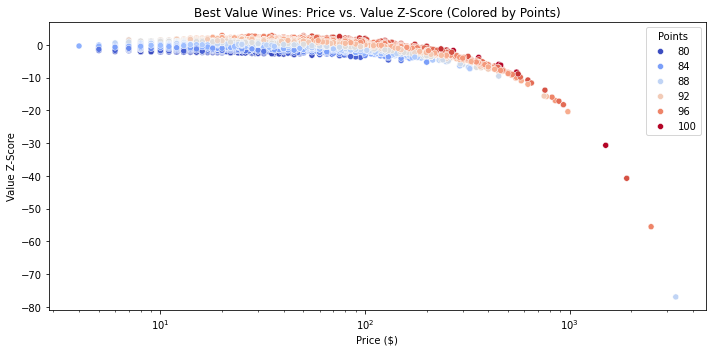

In [15]:
#Plot the price vs. value z-score
plt.figure(figsize=(10, 5))
scatter = sns.scatterplot(data=wine_val, x='price', y='value_z_score', hue='points', palette='coolwarm')
plt.title('Best Value Wines: Price vs. Value Z-Score (Colored by Points)')
plt.xlabel('Price ($)')
plt.ylabel('Value Z-Score')
plt.xscale('log')
plt.legend(title='Points', loc='upper right')
plt.tight_layout()
plt.show()

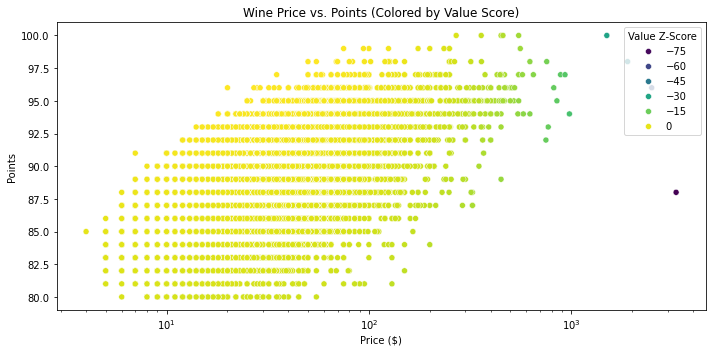

In [16]:
#Plot the price vs. points
plt.figure(figsize=(10, 5))
sns.scatterplot(data=wine_val, x='price', y='points', hue='value_z_score', palette='viridis')
plt.title('Wine Price vs. Points (Colored by Value Score)')
plt.xlabel('Price ($)')
plt.ylabel('Points')
plt.xscale('log')
plt.legend(title='Value Z-Score', loc='upper right')
plt.tight_layout()
plt.show()

In looking at the output, American wines (particularly Syrah from Washington State) are high value wines with high point ratings relative to their price. Austrian grape varieties are also prevalent in the top value wines, with Gruner Veltliner and Blaufrankish showing high value scores. By country, Austria and Germany lead in mean value, suggesting Central European wines deliver excellent quality-to-price.

In contrast, wines like Port, Pinot Grigio, and Champagne perform worst, likely due to reputation-driven premium pricing. And despite their positioning as affordable wines, wines from Argentina and Chile have a low mean value.  

All in all, it appears that the "sweet spot" for wine prices is between 20-55 dollars a bottle in more "under the radar" countries and regions, while regions like Bourdeaux where reputation inflates prices the quality may not justify the cost.